# 03 — Classificação: direção do próximo pregão

A pergunta do modelo é: **com os dados conhecidos ao final do dia t, o preço fechará em alta ou em queda no próximo pregão?**

Comparamos o mesmo algoritmo em duas versões para isolar o valor das notícias: `Somente mercado` e `Mercado + notícias IA`.

In [17]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import TimeSeriesSplit

plt.style.use('seaborn-v0_8-whitegrid')
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = PROJECT_ROOT / 'data/features/energy_market_news_daily.csv'

In [18]:
df = pd.read_csv(DATA_PATH, parse_dates=['date']).sort_values('date')
df = df.dropna(subset=['return', 'direction_next_day']).reset_index(drop=True)
df['direction_next_day'] = df['direction_next_day'].astype(int)
print(f'Observações: {len(df):,}')
print(f'Período: {df.date.min().date()} → {df.date.max().date()}')
print(f'Dias de alta: {df.direction_next_day.mean():.1%}')

Observações: 157
Período: 2026-01-05 → 2026-08-21
Dias de alta: 45.9%


In [19]:
df.head()

,preco_max,preco_min,preco_fecho,quantidade_total,total_ordens_dia,date,news_count,weighted_sum,total_relevance,avg_score,...,high_weighted_sum,high_total_relevance,high_relevance_news_count,high_relevance_signal,high_relevance_signal_ma_2,return,intraday_range,return_next_day,direction_next_day,close_next_day
0,367.0,348.00,348.0,146,88,2026-01-05,14.0,-0.3008,2.99,-0.037857,...,0.0,0.0,0.0,0.0,0.0,0.054545,19.00,0.024425,1,356.5
1,356.5,339.00,356.5,75,55,2026-01-06,13.0,-0.1240,1.82,-0.011538,...,0.0,0.0,0.0,0.0,0.0,0.024425,17.50,0.110799,1,396.0
2,400.0,365.01,396.0,232,161,2026-01-07,14.0,0.0534,1.78,0.022857,...,0.0,0.0,0.0,0.0,0.0,0.110799,34.99,-0.080808,0,364.0
3,384.0,364.00,364.0,72,53,2026-01-08,12.0,0.1886,1.76,0.031667,...,0.0,0.0,0.0,0.0,0.0,-0.080808,20.00,-0.016484,0,358.0
4,375.0,349.01,358.0,61,37,2026-01-09,12.0,0.0410,1.46,0.012500,...,0.0,0.0,0.0,0.0,0.0,-0.016484,25.99,-0.030726,0,347.0


## Features e modelo

O baseline recebe o retorno do pregão atual. A versão com IA acrescenta o sinal composto apenas por notícias com `relevance >= 0.70`, suavizado em 2 pregões. O filtro reduz matérias pouco materiais e a média reduz ruído diário. Poucas features e árvores rasas reduzem o risco de overfitting em uma base curta.

In [20]:
FEATURE_SETS = {
    'Somente mercado': ['return'],
    'Mercado + notícias IA': ['return', 'high_relevance_signal_ma_2'],
}

def build_model():
    return RandomForestClassifier(
        n_estimators=500, max_depth=2, min_samples_leaf=10,
        class_weight='balanced', random_state=42, n_jobs=1,
    )

## Validação walk-forward

São quatro testes de 30 pregões. Em cada janela, o treino contém somente datas anteriores ao teste e cresce ao longo do tempo.

In [21]:
splitter = TimeSeriesSplit(n_splits=4, test_size=30)
metrics, predictions = [], []
for fold, (train_idx, test_idx) in enumerate(splitter.split(df), start=1):
    train, test = df.iloc[train_idx], df.iloc[test_idx]
    assert train['date'].max() < test['date'].min()
    for model_name, features in FEATURE_SETS.items():
        model = build_model()
        model.fit(train[features], train['direction_next_day'])
        predicted = model.predict(test[features])
        probability = model.predict_proba(test[features])[:, 1]
        actual = test['direction_next_day']
        metrics.append({
            'fold': fold, 'model': model_name,
            'train_end': train.date.max(), 'test_start': test.date.min(), 'test_end': test.date.max(),
            'accuracy': accuracy_score(actual, predicted),
            'balanced_accuracy': balanced_accuracy_score(actual, predicted),
            'roc_auc': roc_auc_score(actual, probability),
        })
        predictions.extend({'date': d, 'fold': fold, 'model': model_name, 'actual': int(y), 'prediction': int(p), 'probability_up': float(prob)} for d, y, p, prob in zip(test.date, actual, predicted, probability))
metrics = pd.DataFrame(metrics)
predictions = pd.DataFrame(predictions)

In [22]:
summary = metrics.groupby('model').agg(
    accuracy=('accuracy', 'mean'), accuracy_std=('accuracy', 'std'),
    balanced_accuracy=('balanced_accuracy', 'mean'), roc_auc=('roc_auc', 'mean'),
).sort_values('accuracy')
display(summary.style.format({'accuracy': '{:.1%}', 'accuracy_std': '{:.1%}', 'balanced_accuracy': '{:.1%}', 'roc_auc': '{:.3f}'}))
display(metrics.pivot(index='fold', columns='model', values='accuracy').style.format('{:.1%}'))

,accuracy,accuracy_std,balanced_accuracy,roc_auc
model,,,,
Somente mercado,51.7%,6.4%,49.9%,0.482
Mercado + notícias IA,54.2%,5.7%,51.9%,0.483


model,Mercado + notícias IA,Somente mercado
fold,,
1,53.3%,53.3%
2,56.7%,46.7%
3,46.7%,46.7%
4,60.0%,60.0%


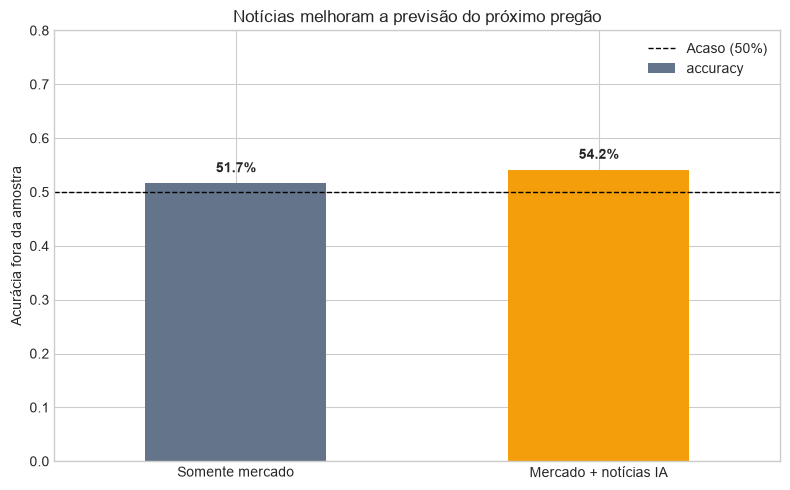

Ganho médio com notícias: +2.5% pontos percentuais


In [23]:
baseline = summary.loc['Somente mercado', 'accuracy']
with_news = summary.loc['Mercado + notícias IA', 'accuracy']
gain = with_news - baseline
ax = summary['accuracy'].plot.bar(figsize=(8, 5), color=['#64748b', '#f59e0b'], rot=0)
ax.axhline(.5, color='black', linestyle='--', linewidth=1, label='Acaso (50%)')
ax.set(ylim=(0, .8), xlabel='', ylabel='Acurácia fora da amostra', title='Notícias melhoram a previsão do próximo pregão')
for i, value in enumerate(summary['accuracy']): ax.text(i, value + .02, f'{value:.1%}', ha='center', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Ganho médio com notícias: {gain:+.1%} pontos percentuais')

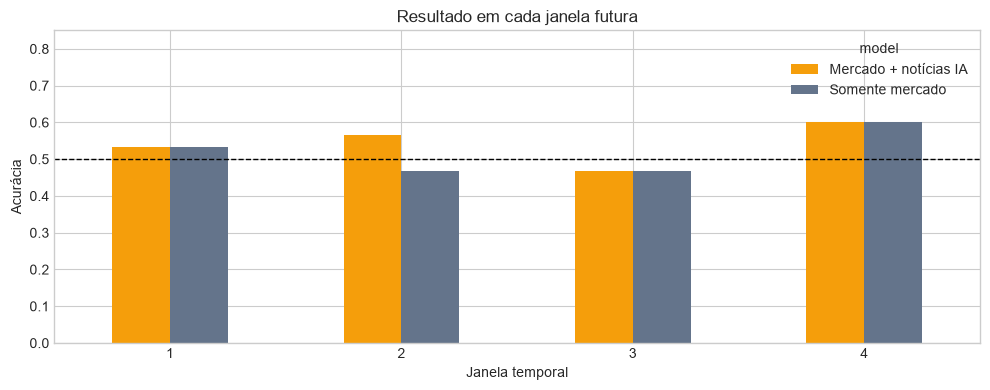

In [24]:
fold_table = metrics.pivot(index='fold', columns='model', values='accuracy')
fold_table.plot.bar(figsize=(10, 4), color=['#f59e0b', '#64748b'], rot=0)
plt.axhline(.5, color='black', linestyle='--', linewidth=1)
plt.ylim(0, .85); plt.xlabel('Janela temporal'); plt.ylabel('Acurácia'); plt.title('Resultado em cada janela futura')
plt.tight_layout(); plt.show()

## Conclusão

A comparação altera apenas a presença da feature de notícias. Se a acurácia média de `Mercado + notícias IA` for maior, temos evidência fora da amostra de que a conversão de texto não estruturado em números adicionou informação. Como a série ainda é curta, o resultado é uma demonstração didática, não uma garantia de desempenho futuro ou recomendação de investimento.